## Statistical Rethinking - Chapter 2

Work through problems from the book below.

## Setup

Run this cell first to import required libraries.

In [4]:
import os
import arviz as az
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random

import numpyro  
import numpyro.distributions as dist
import numpyro.optim as optim
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLaplaceApproximation
from typing import List

az.style.use("arviz-darkgrid")
numpyro.set_platform("cpu")

print("✓ Environment ready!")
print(f"NumPyro version: {numpyro.__version__}")

✓ Environment ready!
NumPyro version: 0.21.0


## Work Area

Add cells below for your solutions. Use:
- `B` key (in command mode) to insert cell below
- `M` key to convert cell to markdown (for notes/explanations)
- `Y` key to convert cell to code
- `Shift+Enter` to run cell and move to next

## 2M1

In [22]:
def plot_grid_posterior_distrbutions(observations, prior_type = 'flat'):
    num_points=20
    water_observations = [x for x in observations if x  == 'W']
    num_points = 20
    
    # grid
    p_grid = jnp.linspace(start=0, stop=1, num=num_points)

    if prior_type == 'flat': 
        prior = jnp.repeat(1, num_points)
    elif prior_type == 'step':
        prior = jnp.where(p_grid < 0.5, 0, 1)
    
    # compute likelihood at each value in grid
    likelihood = jnp.exp(dist.Binomial(total_count=len(observations), probs=p_grid).log_prob(len(water_observations)))
    
    # compute product of likelihood and prior
    unstd_posterior = likelihood * prior
    
    # standardize the posterior, so it sums to 1
    posterior = unstd_posterior / jnp.sum(unstd_posterior)
    
    #plot
    plt.plot(p_grid, posterior, "-o")
    plt.xlabel("probability of water")
    plt.ylabel("posterior probability")
    plt.title("Observations: " + " ".join(observations))
    plt.show()


# (1)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


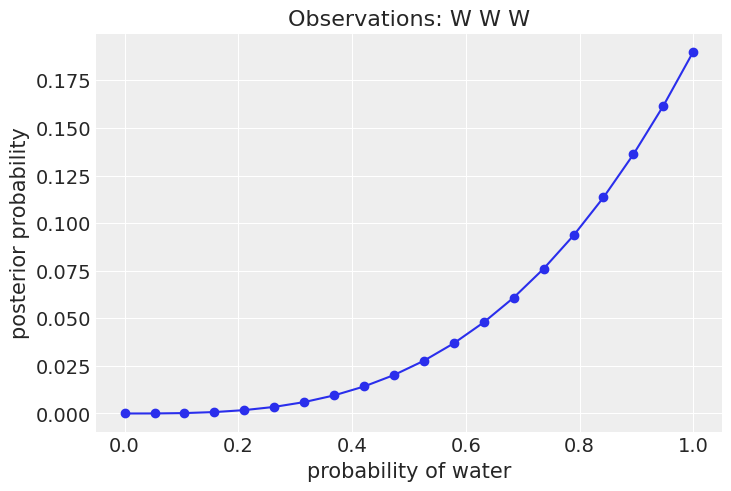

In [11]:
observations = ['W', 'W', 'W']
plot_grid_posterior_distrbutions(observations)

# (2)

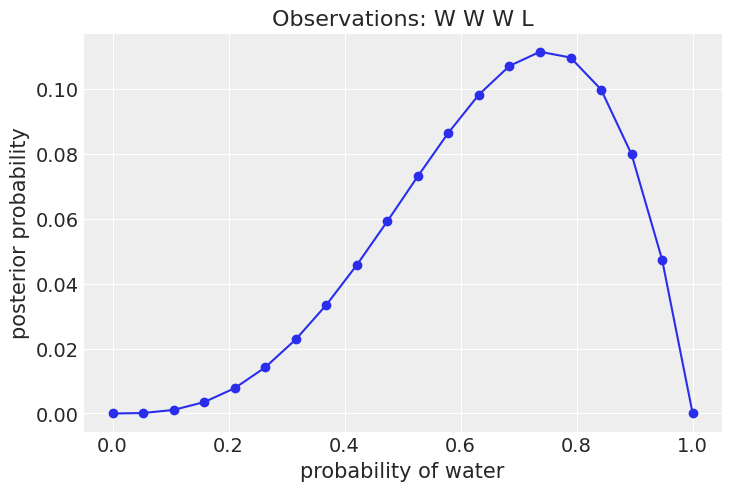

In [12]:
observations = ['W', 'W', 'W', "L"]
plot_grid_posterior_distrbutions(observations)

# (3)


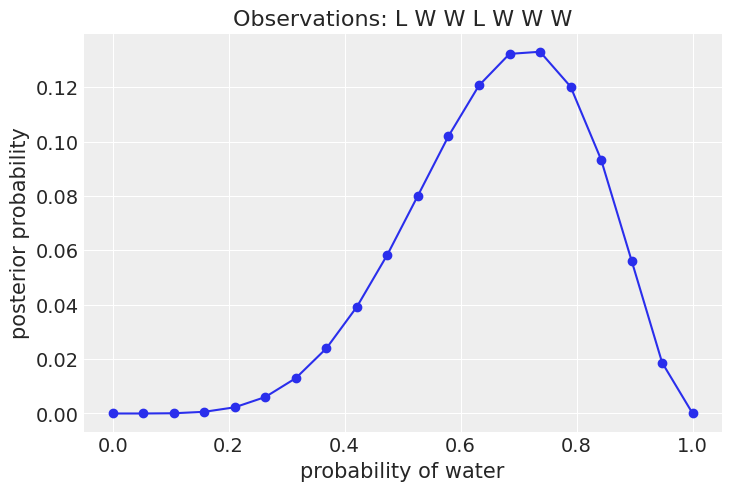

In [16]:
observations = ["L", "W", "W", "L", "W", "W", "W"]
plot_grid_posterior_distrbutions(observations)

## 2M1

# (1)


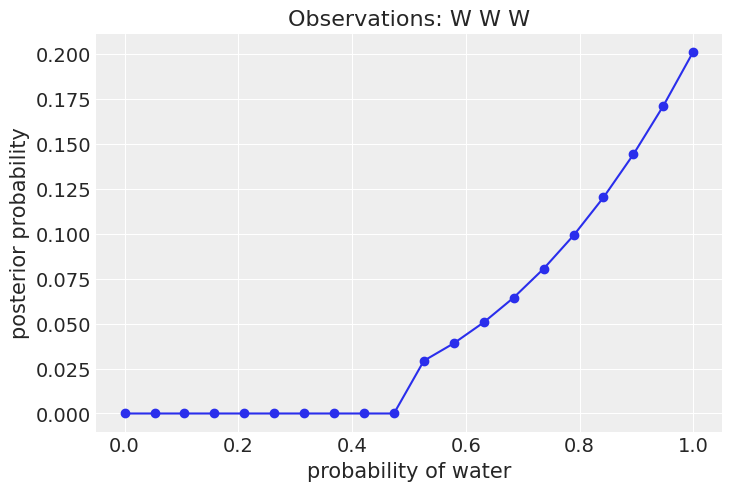

In [24]:
observations = ['W', 'W', 'W']
plot_grid_posterior_distrbutions(observations, prior_type = 'step')

## (2)


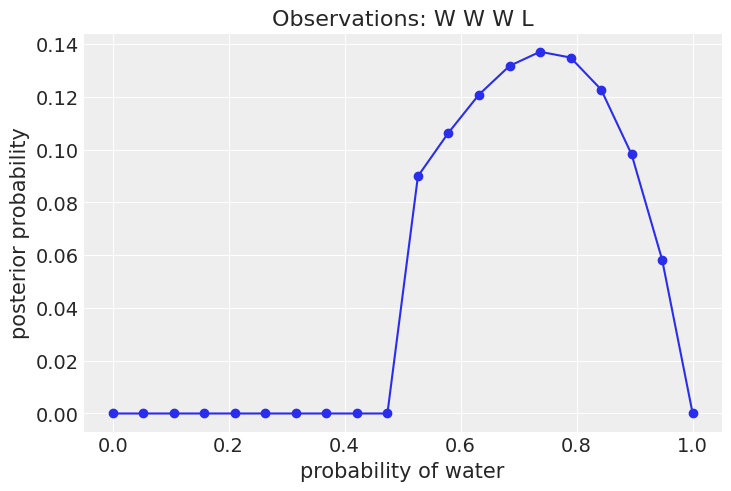

In [27]:
observations = ['W', 'W', 'W', "L"]
plot_grid_posterior_distrbutions(observations, prior_type = 'step')

# 





(3)


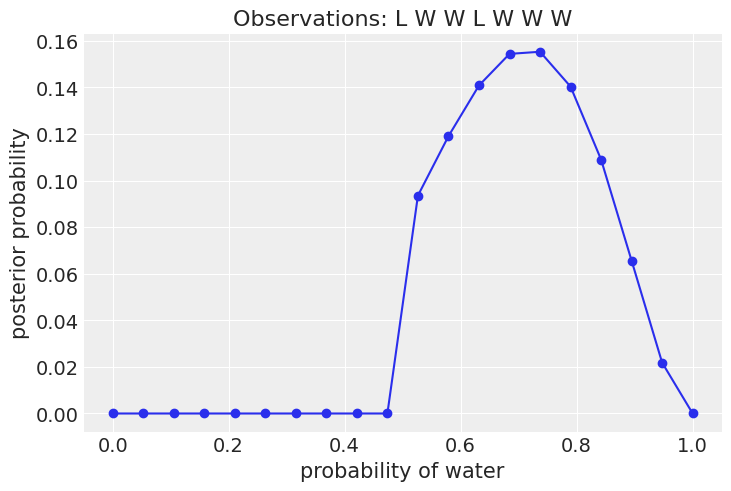

In [25]:
observations = ["L", "W", "W", "L", "W", "W", "W"]
plot_grid_posterior_distrbutions(observations, prior_type = 'step')

## 2M2

In [31]:
p_toss_was_each_planet = .5
p_land_on_earth = .3
p_land_on_mars = 1.0

p_land_per_toss = (p_land_on_earth * p_toss_was_each_planet) + (p_land_on_mars * p_toss_was_each_planet)

p_land_given_earth = (p_land_on_earth * p_toss_was_each_planet) / p_land_per_toss

print(p_land_given_earth)

0.23076923076923075


## 2H1

In [32]:
p_species_a = .5
p_species_a_twins = .1
p_species_b_twins = .2

p_twins_per_birth = (p_species_a_twins * p_species_a) + (p_species_b_twins * (1 - p_species_a))

p_species_a_given_twins = (p_species_a_twins * p_species_a) / p_twins_per_birth
p_species_b_given_twins = (p_species_b_twins * (1-p_species_a)) / p_twins_per_birth

p_second_baby_twins = p_species_a_given_twins * p_species_a_twins + p_species_b_given_twins * p_species_b_twins

print(p_second_baby_twins)

0.16666666666666666


## 2H2

In [37]:
print(p_species_a_given_twins)

0.3333333333333333


## 2H3

In [40]:
p_species_a_given_only_child = ((1-p_species_a_twins) * p_species_a_given_twins) / ((1-p_species_a_twins) * p_species_a_given_twins + (1-p_species_b_twins) * p_species_b_given_twins)
print(p_species_a_given_only_child)

0.36000000000000004


## 2H4

In [42]:
p_species_a = .5
p_species_a_test_for_a = .8
p_species_a_test_for_b = (1 - .65)

p_test_returns_a = (p_species_a_test_for_a * p_species_a) + (p_species_a_test_for_b * (1 - p_species_a))

p_species_a_given_a_test_result = (p_species_a_test_for_a * p_species_a) / p_test_returns_a

print(f"Probability species A from test only: {p_species_a_given_a_test_result}")

p_species_a = p_species_a_given_only_child
p_species_a_test_for_a = .8
p_species_a_test_for_b = (1 - .65)

p_test_returns_a = (p_species_a_test_for_a * p_species_a) + (p_species_a_test_for_b * (1 - p_species_a))

p_species_a_given_a_test_result = (p_species_a_test_for_a * p_species_a) / p_test_returns_a

print(f"Probability species A from test and births: {p_species_a_given_a_test_result}")

Probability species A from test only: 0.6956521739130436
Probability species A from test and births: 0.5625
